# 4. Breaking wave loads

In [58]:
import numpy as np              
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrow

plt.rcParams['figure.figsize'] = (15, 8)   # set the width and height of plots in inches
plt.rcParams.update({'font.size': 13})     # change this value to your desired font size

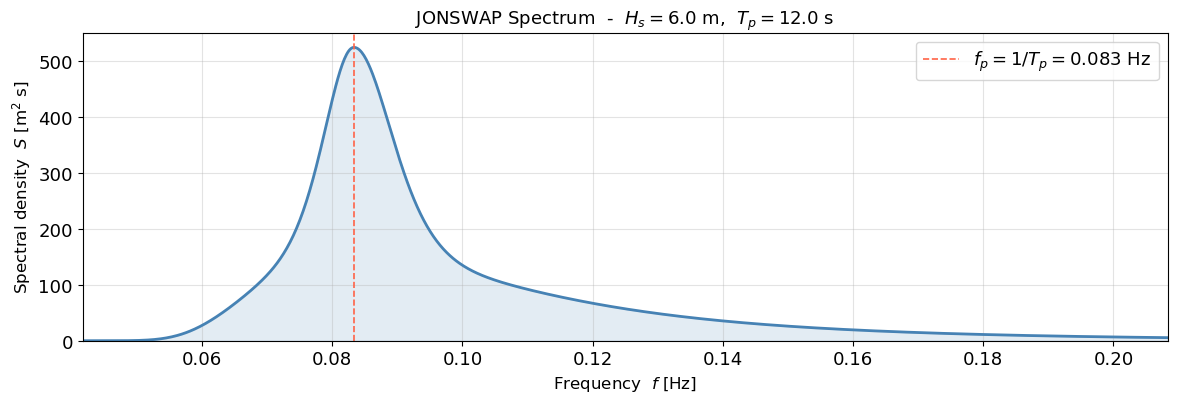

In [59]:
# Parameters
R     = 4.0         # Cylinder radius (m)
rho   = 1025.0      # Water density (kg/m³)
g     = 9.81        # Gravitational acceleration (m/s²)
h     = 35.0        # Water depth (m)

# JONSWAP
H_s = 6.0           # Significant wave height [m]
T_p = 12.0          # Peak period [s]
f_p = 1.0 / T_p

def jonswap(f, H_s, T_p, gamma=3.3):
    """
    JONSWAP wave spectrum E(f) [m^2 s].
    """
    fp = 1.0 / T_p
    alpha = 0.0624 / (0.230 + 0.0336 * gamma - 0.185 * (1.9 + gamma) ** -1)
    tau = np.where(f <= fp, 0.07, 0.09)
    r = np.exp(-(f - fp) ** 2 / (2 * tau**2 * fp**2))
    S = (
        2 * np.pi * alpha * H_s**2
        * (f ** (-5) / fp ** (-4))
        * np.exp(-5 / 4 * (f / fp) ** (-4))
        * gamma ** r
    )
    return S

# Plot JONSWAP
f_plot = np.linspace(0.5 * f_p, 2.5 * f_p, 1000)
S_plot = jonswap(f_plot, H_s, T_p)

fig, ax1 = plt.subplots(1, 1, figsize=(14, 4))

ax1.plot(f_plot, S_plot, color="steelblue", lw=2)
ax1.axvline(f_p, color="tomato", lw=1.2, ls="--", label=f"$f_p = 1/T_p = {f_p:.3f}$ Hz")
ax1.fill_between(f_plot, S_plot, alpha=0.15, color="steelblue")
ax1.set_xlabel("Frequency  $f$ [Hz]", fontsize=12)
ax1.set_ylabel("Spectral density  $S$ [m$^2$ s]", fontsize=12)
ax1.set_title(f"JONSWAP Spectrum  -  $H_s = {H_s}$ m,  $T_p = {T_p}$ s", fontsize=13)
ax1.set_xlim(f_plot[0], f_plot[-1])
ax1.set_ylim(bottom=0)
ax1.grid(True, alpha=0.35)
ax1.legend()

In [60]:
#solve the dispertion relation using Newton-Rhapson
def waveNumber_dispertionRelation_NewtonRhapson(T, d, tolerance=1e-6):
    """
    Solve the dispersion relation for water waves using Newton-Raphson method.
    
    The dispersion relation is: ω² = gk·tanh(kd)
    Or equivalently: (2π/T)² = gk·tanh(kd)
    
    We solve: f(k) = gk·tanh(kd) - (2π/T)² = 0
    
    Parameters:
    -----------
    T : float
        Wave period (seconds)
    d : float
        Water depth (meters)
    tolerance : float
        Convergence tolerance (default: 1e-6)
    
    Returns:
    --------
    k : float
        Wave number (rad/m)
    """
    g = 9.81  # Gravitational acceleration (m/s²)
    omega = 2 * np.pi / T  # Angular frequency
    omega_squared = omega ** 2
    
    # Initial guess for k using deep water approximation: k ≈ ω²/g
    k = omega_squared / g
    
    # Newton-Raphson iteration
    max_iterations = 100
    for iteration in range(max_iterations):
        # Calculate f(k) = g*k*tanh(k*d) - ω²
        tanh_kd = np.tanh(k * d)
        f = g * k * tanh_kd - omega_squared
        
        # Calculate f'(k) = g*tanh(k*d) + g*k*d*sech²(k*d)
        # where sech²(k*d) = 1 - tanh²(k*d)
        sech_squared_kd = 1 - tanh_kd ** 2
        df = g * tanh_kd + g * k * d * sech_squared_kd
        
        # Newton-Raphson update: k_new = k_old - f(k)/f'(k)
        k_new = k - f / df
        
        # Check convergence
        if abs(k_new - k) < tolerance:
            return k_new
        
        k = k_new
    
    # If max iterations reached without convergence
    print(f"Warning: Newton-Raphson did not converge within {max_iterations} iterations")
    return k

### 4.1 Slamming waves

In [61]:
# SEA STATE PARAMETERS
T_m01 = T_p / 1.07
w_bar   = 2*np.pi/T_m01 # mean angular frequency [rad/s]
k_bar = waveNumber_dispertionRelation_NewtonRhapson(T_m01, h)
L_bar = 2 * np.pi / k_bar  # wavelength (m)
L_0 = T_m01**2 *g / (2 * np.pi)  # deep water wavelength (m)
print(h, k_bar, L_bar)
print(f'{T_m01=}, {L_bar=}, {L_0=}')

# Miche
break_miche = 0.14 * np.tanh(k_bar * h ) * L_bar
print(f'kd={h* k_bar:.2f}')
print(f'Miche breaking threshold: H_max = {break_miche:.2f} m') 

# Breaking criterion parameters (Longuet-Higgins / Kamphuis)
R_wave  = k_bar * H_s   # characteristic steepness parameter [-]
beta_0  = 0.5
beta    = beta_0 * (1 + beta_0/2)   # = 0.625
alpha_0 = 0.4                        # depth-based fraction
print(f'{R_wave=}')

def breaking_threshold(R_wave, h, H_s, beta, alpha_0):
    """
    Breaking wave crest height threshold alpha/H_s.
    min of steepness criterion and depth criterion.
    """
    steep = beta / R_wave
    depth = alpha_0 * h / H_s
    print(f'steep={steep :.3f}, depth={depth:.3f}')
    print(f'steep={steep * 2* H_s :.3f}, depth={depth *2  *H_s:.3f}')
    return min(steep, depth) * H_s

breaking_threshold(R_wave, h, H_s, beta, alpha_0)

def rayleigh_pdf(a, H_s):
    """Linear (Rayleigh) wave amplitude PDF — standard JONSWAP assumption."""
    return 16 * a / H_s**2 * np.exp(-8 * a**2 / H_s**2)

def nonlinear_pdf(r, H_s, R):
    """
    Nonlinear crest amplitude PDF (Dawson 1993 / Paulsen et al. 2019).
    r: nonlinear crest amplitude (envelope)
    Accounts for second-order Stokes wave asymmetry.
    """
    term1 = 16 * r / H_s**2 * np.exp(-8 * r**2 / H_s**2)
    term2 = (1 - 1.5 * R * r / H_s)
    term3 = np.exp(-8 * R * r**3 / H_s**3)
    result = term1 * term2 * term3
    return np.maximum(result, 0)  # PDF cannot be negative


35.0 0.03713378614685107 169.20400420069737
T_m01=11.214953271028037, L_bar=np.float64(169.20400420069737), L_0=196.3740403610228
kd=1.30
Miche breaking threshold: H_max = 20.41 m
R_wave=np.float64(0.22280271688110642)
steep=2.805, depth=2.333
steep=33.662, depth=28.000


In [62]:
print(1.4 * h * 0.75)

36.75


### 4.2 Slamming-load timeseries and point of application

In [63]:
# Sample slamming wave characteristics
H_b = break_miche   # Wave breaking height [m]


# STEP 1: Derived wave parameters
# =============================================================================
T_s = T_p / 1.07    # Sample wave breaking period [s]
omega = 2 * np.pi / T_s 
k = waveNumber_dispertionRelation_NewtonRhapson(T_s, h)
c = omega / k                   # wave speed at breaking
lam = 0.46                      # Curling factor for plunging breakers

t = 13/32 * R /c # Duration of the impact

x = np.linspace(0, R, 100)
eta_b = R - np.sqrt(R**2 - x**2)
eta_b = 0.7 * H_b        # (m) — crest elevation
ell = lam * eta_b          # effective length of the impact zone # λ * η_b  (m)

print("=" * 55)
print("  Parameters")
print("=" * 55)
print(f"\n  Wave period          T_s  = {T_s:.2f} s")
print(f"  Breaking wave height H_b  = {H_b:.2f} m")
print(f"  Wave celerity        c    = {c:.3f} m/s")
print(f"  Crest elevation      η_b  = {eta_b:.3f} m")
print(f"  Curling factor       λ    = {lam}")
print(f"  Impact zone height   λη_b = {ell:.3f} m")
print(f"  Cylinder radius      R    = {R:.2f} m")

# STEP 2: Time axis — two phases defined in the 3D model
#  Phase 1 (F1): 0  <=  t  <=  (1/8)*(R/c)   =>  0 <= x <= R/√2
#  Phase 2 (FI): defined with shifted time t' = t - (1/32)*(R/c)
#                for  (3/32)*(R/c)  <=  t'  <=  (12/32)*(R/c)
# =============================================================================

# Phase 1 time limits
t1_end = (1/8) * (R / c)                                # end of Phase 1

# Phase 2 uses shifted time t' = t - (1/32)*(R/c)
t2_prime_start = (3/32) * (R / c)                       # t' start
t2_prime_end = (12/32) * (R / c)                        # t' end  (= 13R/32c total)

t_shift = (1/32) * (R / c)                              # time offset for t'
t2_start = t2_prime_start+ t_shift                 # t' start
t2_end = t2_prime_end + t_shift         # t' end  (= 13R/32c total)
t_check_end = (13/32) * (R / c)                         # t end check (should match t2_end_shifted)

# Full time vector covering both phases
N = 2000
t_arr = np.linspace(0, t2_end * 1.3, N)

print()
print("=" * 55)
print("  TIME SERIES")
print("=" * 55)
print(f"\n  Phase 1: 0 <= t <= {t1_end:.3f} s")
print(f"  Phase 2: {t2_start:.3f} s <= t' <= {t2_end:.3f} s")
print(f"  Phase 2 shifted time: {t2_prime_start:.3f} s <= t <= {t2_prime_end:.3f} s")
print(f'  Total duration: {t2_end:.3f} s (end t2) should be {t_check_end:.3f} s (13/32 R/c)')

  Parameters

  Wave period          T_s  = 11.21 s
  Breaking wave height H_b  = 20.41 m
  Wave celerity        c    = 15.087 m/s
  Crest elevation      η_b  = 14.288 m
  Curling factor       λ    = 0.46
  Impact zone height   λη_b = 6.572 m
  Cylinder radius      R    = 4.00 m

  TIME SERIES

  Phase 1: 0 <= t <= 0.033 s
  Phase 2: 0.033 s <= t' <= 0.108 s
  Phase 2 shifted time: 0.025 s <= t <= 0.099 s
  Total duration: 0.108 s (end t2) should be 0.108 s (13/32 R/c)


In [64]:
# STEP 3: Force calculation — Phase 1 (F1) and Phase 2 (FI)
# =============================================================================
def F1(t, lam, eta_b, rho, R, c):
    """
    Phase 1 slamming force — wave front rising up the cylinder face.

    F1 = λ·η_b·ρ·R·c² · (2π - 2·√(c/R·t) · artanh(√(1 - (c/(4R)·t))))

    Valid for: 0 ≤ t ≤ (1/8)·(R/c)
    At t=0: F1 = λ·η_b·ρ·R·c²·2π  (limit value, Wagner peak)
    """
    if t <= 0:
        return lam * eta_b * rho * R * c**2 * 2 * np.pi
    arg_sqrt = c / R * t
    tanh_arg = np.clip(1 - (c / (4 * R)) * t, 0, 1)
    tanh_val = np.arctanh(np.sqrt(tanh_arg)) if tanh_arg < 1 else 0.0
    return lam * eta_b * rho * R * c**2 * (
        2 * np.pi - 2 * np.sqrt(arg_sqrt) * tanh_val
    )


def FI(t_prime, lam, eta_b, rho, R, c):
    """
    Phase 2 slamming force — wave wrapping around cylinder sides.

    FI = λ·η_b·ρ·R·c² · (π·√(1/(6·(c/R)·t')) 
                          - (4/3)·√(8c/(3R)·t') · artanh(√(1 - (c/R)·t') · √(6c/R·t')))

    Valid for: (3/32)·(R/c) ≤ t' ≤ (12/32)·(R/c)
    """
    ratio = c / R * t_prime
    term1 = np.pi * np.sqrt(1 / (6 * ratio))
    inner = np.sqrt(1 - ratio * np.sqrt(6 * ratio))
    term2 = (8 /3 * ratio)**(1/4) * np.arctanh(np.clip(inner, 0, 0.9999))
    return lam * eta_b * rho * R * c**2 * (term1 - term2)


# Build composite force time history
F_arr = np.zeros(N)

for i, t in enumerate(t_arr):
    if t <= t1_end:
        # Phase 1
        F_arr[i] = F1(t, lam, eta_b, rho, R, c)
    else:
        # Phase 2 — use shifted time t'
        t_prime = t - t_shift
        if t2_prime_start <= t_prime <= t2_prime_end:
            F_arr[i] = FI(t_prime, lam, eta_b, rho, R, c)
        else:
            F_arr[i] = 0.0  # outside defined range


# STEP 4: Key results
# =============================================================================
F_max = np.max(F_arr)
tons_max = F_max / 1e6 * 101.9716213  # Convert N to tons-force
t_at_max = t_arr[np.argmax(F_arr)]
duration = t2_end + t_shift   # total impact duration (s)

print(f"  --- RESULTS ---")
print(f"  Peak slamming force  F_max  = {F_max/1e6:.4f} MN  ({F_max:.2f} N)")
print(f"  Peak slamming force  F_max  = {tons_max:.4f} tons-force")
print(f"  Time of peak         t_peak = {t_at_max*1000:.4f} ms")
print(f"  Total impact duration       = {duration*1000:.4f} ms")
print(f"  Impact length on pile  λη_b   = {ell:.3f} m above SWL")
print(f"  Impact zone top      η_b    = {eta_b:.3f} m above SWL")
print(f"  Impact zone bottom   η_b-λη = {eta_b - ell:.3f} m above SWL")
print(f"  Impact point         η_b-λη/2 = {eta_b - ell/2:.3f} m above SWL")

  --- RESULTS ---
  Peak slamming force  F_max  = 38.5400 MN  (38539951.65 N)
  Peak slamming force  F_max  = 3929.9814 tons-force
  Time of peak         t_peak = 0.0000 ms
  Total impact duration       = 115.9912 ms
  Impact length on pile  λη_b   = 6.572 m above SWL
  Impact zone top      η_b    = 14.288 m above SWL
  Impact zone bottom   η_b-λη = 7.715 m above SWL
  Impact point         η_b-λη/2 = 11.002 m above SWL


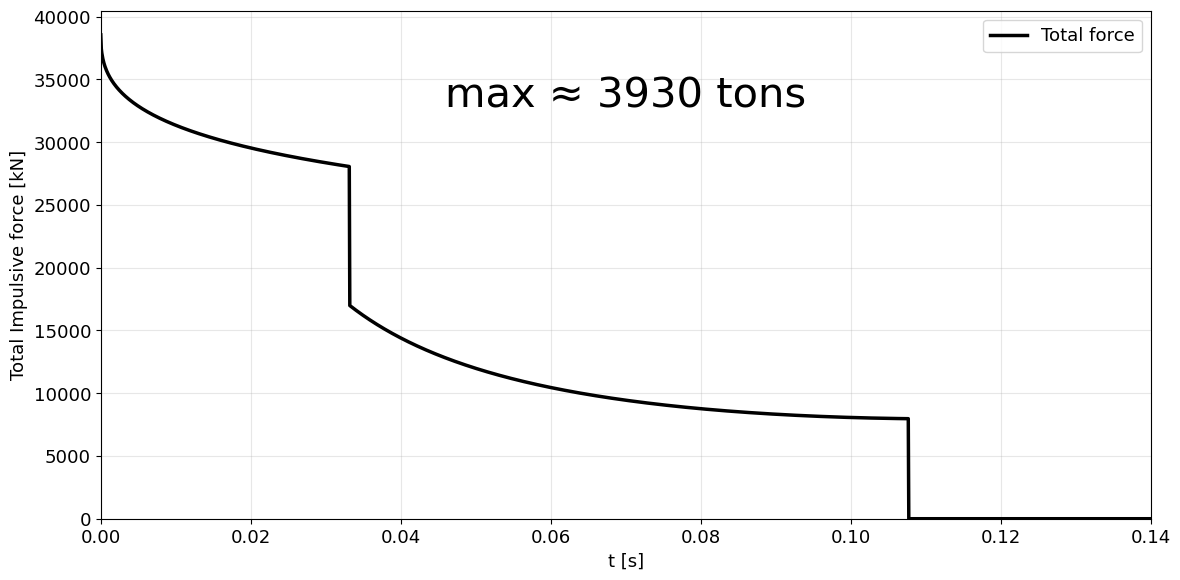

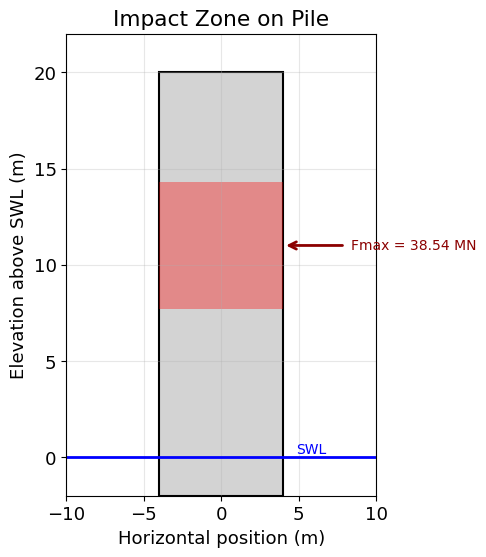

<Figure size 1500x800 with 0 Axes>

In [65]:
# STEP 5: Plot
# =============================================================================
plt.figure(figsize=(12,6))

plt.plot(t_arr, F_arr/1000, color='black', linewidth=2.5, label="Total force")
plt.xlabel("t [s]", fontsize=13)
plt.ylabel("Total Impulsive force [kN]", fontsize=13)
plt.text(
    0.5*(t_arr.max()),
    0.85*(F_max/1000),
    f"max ≈ {tons_max:.0f} tons",
    fontsize=30,
    ha='center'
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0, t_arr.max())
plt.ylim(0, np.max(F_arr/1000)*1.05)
plt.tight_layout()
plt.show()

plt.figure(figsize=(4,6))

pile_height = eta_b * 1.4
plt.xlim(-R*2.5, R*2.5)
plt.ylim(-2, pile_height + 2)

# Pile
pile = Rectangle((-R, -2), 2*R, pile_height+2,
                 facecolor='lightgray', edgecolor='black', linewidth=1.5)
plt.gca().add_patch(pile)

# Still water level
plt.axhline(0, color='blue', linewidth=2)
plt.text(R*1.2, 0.2, "SWL", color='blue', fontsize=10)

# Impact zone
impact_bot = eta_b - ell
impact = Rectangle((-R, impact_bot), 2*R, ell,
                   facecolor='red', alpha=0.35)
plt.gca().add_patch(impact)

# Force arrow
y_mid = (impact_bot + eta_b) / 2
plt.annotate("",
             xy=(R, y_mid),
             xytext=(R*2.0, y_mid),
             arrowprops=dict(arrowstyle="->", lw=2, color="darkred"))

plt.text(R*2.1, y_mid,
         f"Fmax = {F_max/1e6:.2f} MN",
         color="darkred", va="center", fontsize=10)

# Labels
plt.xlabel("Horizontal position (m)")
plt.ylabel("Elevation above SWL (m)")
plt.title("Impact Zone on Pile")

plt.grid(alpha=0.3)
plt.show()

plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/wienke_oumeraci_slamming.png", dpi=150, bbox_inches='tight')
# print("\n  Plot saved to wienke_oumeraci_slamming.png")
plt.show()

Questions: 
- What to wave period to take? Ppt seems to say $T_p/1.07$ but i can also get it from $T_{breaking}$?

### 4.3 Apply slamming load to wind-turbine model (modal transient)

Deze sectie gebruikt de slamming-load tijdreeks `F_arr(t)` uit 4.2 als externe topbelasting op het 2-segment beam-model.

Methode:
- vrije-trillingsmodes via slide/Euler-Bernoulli model,
- modale projectie,
- transiënte respons met Duhamel-convolutie,
- energie-inhoud via FFT/PSD.

In [66]:
import sympy as sp

# Structural model parameters (Assignment 2.1)
D_turb = 8.0
t_wall = 0.1
H_turb = 150.0
M_top = 1e6
J_top = 1.6e9
E = 210e9
rho_steel = 7850.0
rho_water = rho
T_axial = 0.0

Di = D_turb - 2.0 * t_wall
A = np.pi / 4.0 * (D_turb**2 - Di**2)
I = np.pi / 64.0 * (D_turb**4 - Di**4)
EI = E * I

# Added mass coefficient from DNV-style lookup (same style as other notebook)
K_rough = 0.05
Tp_ref = T_p
omega_ref = 2.0 * np.pi / Tp_ref
k_ref = waveNumber_dispertionRelation_NewtonRhapson(Tp_ref, h)
zeta_a_ref = H_s / 2.0
u_a_ref = omega_ref * zeta_a_ref / np.sinh(k_ref * h)
KC_ref = u_a_ref * Tp_ref / D_turb
e_rough = K_rough / D_turb

if KC_ref < 5.0:
    Cm_dnv = 1.8 if e_rough < 0.001 else (1.7 if e_rough < 0.01 else 1.6)
elif KC_ref < 10.0:
    Cm_dnv = 1.6 if e_rough < 0.001 else (1.5 if e_rough < 0.01 else 1.4)
else:
    Cm_dnv = 1.2

Ca = float(Cm_dnv - 1.0)
m1 = rho_steel * A + rho_water * Ca * np.pi * D_turb**2 / 4.0
m2 = rho_steel * A

# Build free-vibration matrix K(omega)
z_sym, omega_sym = sp.symbols('z_sym omega_sym', real=True, positive=True)
m1_sym, m2_sym = sp.symbols('m1_sym m2_sym', positive=True, real=True)

alpha1_sq = (T_axial / EI + sp.sqrt((T_axial / EI) ** 2 + 4 * (omega_sym**2 * m1_sym / EI))) / 2
mu1_sq = (-T_axial / EI + sp.sqrt((T_axial / EI) ** 2 + 4 * (omega_sym**2 * m1_sym / EI))) / 2
alpha2_sq = (T_axial / EI + sp.sqrt((T_axial / EI) ** 2 + 4 * (omega_sym**2 * m2_sym / EI))) / 2
mu2_sq = (-T_axial / EI + sp.sqrt((T_axial / EI) ** 2 + 4 * (omega_sym**2 * m2_sym / EI))) / 2
alpha1, mu1 = sp.sqrt(alpha1_sq), sp.sqrt(mu1_sq)
alpha2, mu2 = sp.sqrt(alpha2_sq), sp.sqrt(mu2_sq)

A1, B1, C1, D1, A2, B2, C2, D2 = sp.symbols('A1 B1 C1 D1 A2 B2 C2 D2')

W1 = A1 * sp.cosh(alpha1 * z_sym) + B1 * sp.sinh(alpha1 * z_sym) + C1 * sp.cos(mu1 * z_sym) + D1 * sp.sin(mu1 * z_sym)
W2 = A2 * sp.cosh(alpha2 * z_sym) + B2 * sp.sinh(alpha2 * z_sym) + C2 * sp.cos(mu2 * z_sym) + D2 * sp.sin(mu2 * z_sym)

W1_1, W1_2, W1_3 = sp.diff(W1, z_sym), sp.diff(W1, z_sym, 2), sp.diff(W1, z_sym, 3)
W2_1, W2_2, W2_3 = sp.diff(W2, z_sym), sp.diff(W2, z_sym, 2), sp.diff(W2, z_sym, 3)

eqs = [
    W1.subs(z_sym, -h),
    W1_1.subs(z_sym, -h),
    W1.subs(z_sym, 0) - W2.subs(z_sym, 0),
    W1_1.subs(z_sym, 0) - W2_1.subs(z_sym, 0),
    W1_2.subs(z_sym, 0) - W2_2.subs(z_sym, 0),
    W1_3.subs(z_sym, 0) - W2_3.subs(z_sym, 0),
    EI * W2_2.subs(z_sym, H_turb) - J_top * omega_sym**2 * W2_1.subs(z_sym, H_turb),
    EI * W2_3.subs(z_sym, H_turb) + M_top * omega_sym**2 * W2.subs(z_sym, H_turb),
]

Cvec = sp.Matrix([A1, B1, C1, D1, A2, B2, C2, D2])
K = sp.Matrix([[sp.diff(expr, cst) for cst in Cvec] for expr in eqs])
K_num_sym = sp.simplify(K.subs({m1_sym: m1, m2_sym: m2}))
K_fun = sp.lambdify(omega_sym, K_num_sym, modules='numpy')

def Knum(w):
    return np.array(K_fun(float(w)), dtype=np.complex128)

def sigma_min(w):
    s = np.linalg.svd(Knum(w), compute_uv=False)
    return float(np.min(s))

def golden_minimize(f, a, b, n_iter=60):
    gr = (np.sqrt(5.0) - 1.0) / 2.0
    c1 = b - gr * (b - a)
    c2 = a + gr * (b - a)
    f1 = f(c1)
    f2 = f(c2)
    for _ in range(n_iter):
        if f1 < f2:
            b, c2, f2 = c2, c1, f1
            c1 = b - gr * (b - a)
            f1 = f(c1)
        else:
            a, c1, f1 = c1, c2, f2
            c2 = a + gr * (b - a)
            f2 = f(c2)
    x = 0.5 * (a + b)
    return x, f(x)

def find_modes(n_modes=3, omega_max=25.0, n_grid=15000, sigma_tol=1e-8, min_spacing=5e-2):
    ws = np.linspace(1e-4, omega_max, n_grid)
    sig = np.array([sigma_min(w) for w in ws], dtype=float)

    refined = []
    for i in range(1, len(ws) - 1):
        if sig[i] < sig[i - 1] and sig[i] < sig[i + 1]:
            w_star, s_star = golden_minimize(sigma_min, ws[i - 1], ws[i + 1])
            refined.append((float(w_star), float(s_star)))

    refined.sort(key=lambda t: t[0])
    uniq = []
    for w_star, s_star in refined:
        if not uniq or abs(w_star - uniq[-1][0]) > min_spacing:
            uniq.append((w_star, s_star))
        elif s_star < uniq[-1][1]:
            uniq[-1] = (w_star, s_star)

    physical = [(w, s) for (w, s) in uniq if s < sigma_tol]
    physical.sort(key=lambda t: t[0])

    omega_n = np.array([w for w, _ in physical[:n_modes]], dtype=float)
    sigma_n = np.array([s for _, s in physical[:n_modes]], dtype=float)
    return omega_n, sigma_n

omega_n, sigma_n = find_modes(n_modes=3)
freq_n = omega_n / (2.0 * np.pi)

print('Eigenfrequenties [Hz]:', [float(f"{f:.6f}") for f in freq_n])

Eigenfrequenties [Hz]: [0.15777, 0.85312, 2.062196]


Applying point load at zF = 11.002 m above SWL
phi_n(zF): [0.088699, -1.290361, -2.217463]
Running transient model with modal damping only.


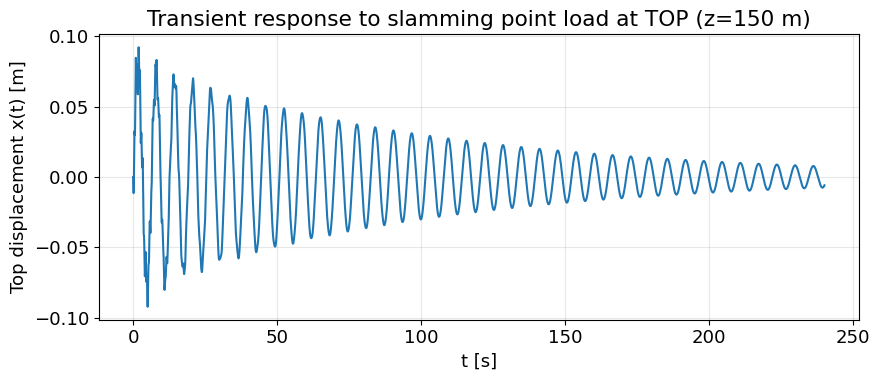

In [78]:
# Modal transient response with modal damping only (no top dashpot)
# p(z,t)=F(t)*delta(z-zF)
W1_num = sp.simplify(W1.subs({m1_sym: m1, m2_sym: m2}))
W2_num = sp.simplify(W2.subs({m1_sym: m1, m2_sym: m2}))

W1_fun = sp.lambdify((z_sym, omega_sym, A1, B1, C1, D1, A2, B2, C2, D2), W1_num, 'numpy')
W2_fun = sp.lambdify((z_sym, omega_sym, A1, B1, C1, D1, A2, B2, C2, D2), W2_num, 'numpy')
W2_dz = sp.diff(W2_num, z_sym)
W2_dz_fun = sp.lambdify((z_sym, omega_sym, A1, B1, C1, D1, A2, B2, C2, D2), W2_dz, 'numpy')

def mode_constants(om):
    Kw = Knum(om)
    _, _, Vh = np.linalg.svd(Kw)
    cst = Vh.conj().T[:, -1]
    return cst / (np.max(np.abs(cst)) + 1e-16)

z1 = np.linspace(-h, 0.0, 600)
z2 = np.linspace(0.0, H_turb, 900)

phi_force = []
phi_top = []
M_modal = []

# Impact point from section 4.2: zF = eta_b - ell/2 (above SWL)
z_force_raw = float(eta_b - ell / 2.0)
z_force = float(np.clip(z_force_raw, -h, H_turb))
if abs(z_force - z_force_raw) > 1e-12:
    print(f'Warning: z_force={z_force_raw:.3f} m outside model domain; clipped to {z_force:.3f} m')

for om in omega_n:
    cst = mode_constants(om)
    A1v, B1v, C1v, D1v, A2v, B2v, C2v, D2v = cst

    phi1 = np.real(np.array(W1_fun(z1, om, A1v, B1v, C1v, D1v, A2v, B2v, C2v, D2v), dtype=np.complex128))
    phi2 = np.real(np.array(W2_fun(z2, om, A1v, B1v, C1v, D1v, A2v, B2v, C2v, D2v), dtype=np.complex128))

    scale = np.real(W2_fun(H_turb, om, A1v, B1v, C1v, D1v, A2v, B2v, C2v, D2v))
    scale = float(scale) if abs(scale) > 1e-14 else 1.0
    phi1 = phi1 / scale
    phi2 = phi2 / scale

    dphiH = np.real(W2_dz_fun(H_turb, om, A1v, B1v, C1v, D1v, A2v, B2v, C2v, D2v)) / scale

    M_n = np.trapezoid(m1 * phi1**2, z1) + np.trapezoid(m2 * phi2**2, z2) + M_top + J_top * (dphiH**2)

    # With delta load at zF, modal force is Qn(t) = phi_n(zF)*F(t)
    if z_force <= 0.0:
        phi_zF = np.real(W1_fun(z_force, om, A1v, B1v, C1v, D1v, A2v, B2v, C2v, D2v)) / scale
    else:
        phi_zF = np.real(W2_fun(z_force, om, A1v, B1v, C1v, D1v, A2v, B2v, C2v, D2v)) / scale

    phi_top_n = np.real(W2_fun(H_turb, om, A1v, B1v, C1v, D1v, A2v, B2v, C2v, D2v)) / scale

    phi_force.append(float(phi_zF))
    phi_top.append(float(phi_top_n))
    M_modal.append(float(M_n))

phi_force = np.array(phi_force, dtype=float)
phi_top = np.array(phi_top, dtype=float)
M_modal = np.array(M_modal, dtype=float)

print(f'Applying point load at zF = {z_force:.3f} m above SWL')
print('phi_n(zF):', [float(f'{v:.6f}') for v in phi_force])

# Time axis and force mapping
zeta = 0.01
fmax = float(np.max(freq_n))
fs = max(100.0 * fmax, 200.0)
dt = 1.0 / fs
t_end = 240.0
nt = int(t_end / dt) + 1
tv = np.linspace(0.0, t_end, nt)

# Use slamming load from section 4.2 (F_arr as function of t_arr)
F_t = np.interp(tv, t_arr, F_arr, left=0.0, right=0.0)

# Modal matrices with modal damping only (no top dashpot)
n_modes = len(omega_n)
M = np.diag(M_modal)
K = np.diag(M_modal * (omega_n**2))
C = np.diag(2.0 * zeta * omega_n * M_modal)
M_inv = np.diag(1.0 / M_modal)

# Integrate coupled modal system using RK4
q = np.zeros((n_modes, nt), dtype=float)
qd = np.zeros((n_modes, nt), dtype=float)

def acc(qv, qdv, fv):
    return M_inv @ (fv - C @ qdv - K @ qv)

for k in range(nt - 1):
    f1 = phi_force * F_t[k]
    f4 = phi_force * F_t[k + 1]
    f2 = 0.5 * (f1 + f4)

    qk = q[:, k]
    vk = qd[:, k]

    a1 = acc(qk, vk, f1)
    k1_q = vk
    k1_v = a1

    a2 = acc(qk + 0.5 * dt * k1_q, vk + 0.5 * dt * k1_v, f2)
    k2_q = vk + 0.5 * dt * k1_v
    k2_v = a2

    a3 = acc(qk + 0.5 * dt * k2_q, vk + 0.5 * dt * k2_v, f2)
    k3_q = vk + 0.5 * dt * k2_v
    k3_v = a3

    a4 = acc(qk + dt * k3_q, vk + dt * k3_v, f4)
    k4_q = vk + dt * k3_v
    k4_v = a4

    q[:, k + 1] = qk + (dt / 6.0) * (k1_q + 2.0 * k2_q + 2.0 * k3_q + k4_q)
    qd[:, k + 1] = vk + (dt / 6.0) * (k1_v + 2.0 * k2_v + 2.0 * k3_v + k4_v)

x_top = phi_top @ q

print('Running transient model with modal damping only.')

plt.figure(figsize=(9, 4))
plt.plot(tv, x_top)
plt.xlabel('t [s]')
plt.ylabel('Top displacement x(t) [m]')
plt.title('Transient response to slamming point load at TOP (z=150 m)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

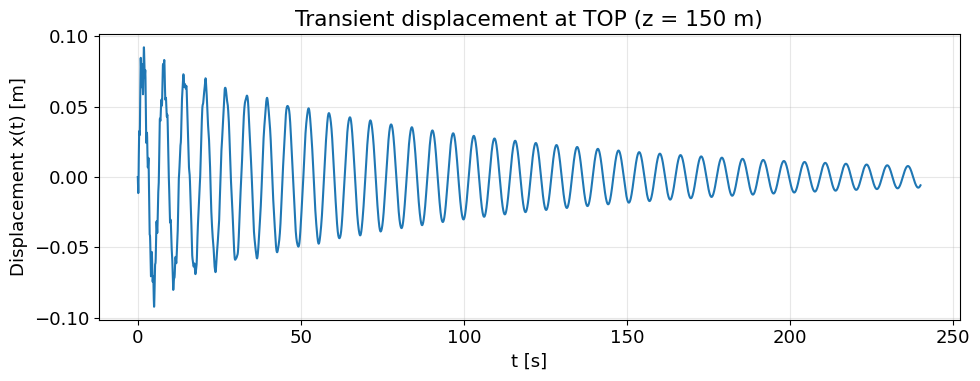

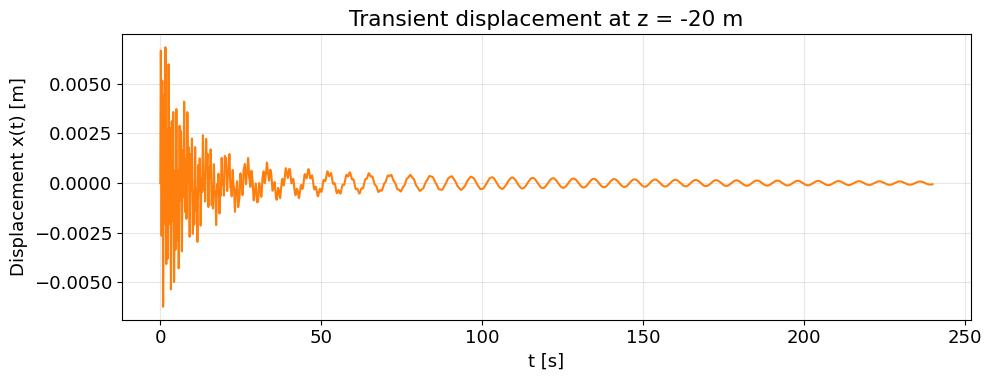

In [75]:
# Time-domain displacement comparison in one code cell: TOP and z = -20 m
z_sel_disp = -20.0

# Reconstruct modal participation at z = -20 m using the same mode normalization
phi_sel_disp = np.zeros(len(omega_n), dtype=float)
for n, om in enumerate(omega_n):
    cst = mode_constants(float(om))
    A1v, B1v, C1v, D1v, A2v, B2v, C2v, D2v = cst

    scale = np.real(W2_fun(H_turb, om, A1v, B1v, C1v, D1v, A2v, B2v, C2v, D2v))
    scale = float(scale) if abs(scale) > 1e-14 else 1.0

    if z_sel_disp <= 0.0:
        phi_sel_disp[n] = float(np.real(
            W1_fun(z_sel_disp, om, A1v, B1v, C1v, D1v, A2v, B2v, C2v, D2v) / scale
        ))
    else:
        phi_sel_disp[n] = float(np.real(
            W2_fun(z_sel_disp, om, A1v, B1v, C1v, D1v, A2v, B2v, C2v, D2v) / scale
        ))

x_sel_disp = phi_sel_disp @ q

# Figure 1: TOP displacement (blue)
plt.figure(figsize=(10, 4))
plt.plot(tv, x_top, lw=1.5, color='tab:blue')
plt.xlabel('t [s]')
plt.ylabel('Displacement x(t) [m]')
plt.title(f'Transient displacement at TOP (z = {H_turb:.0f} m)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 2: Displacement at z = -20 m (orange)
plt.figure(figsize=(10, 4))
plt.plot(tv, x_sel_disp, lw=1.5, color='tab:orange')
plt.xlabel('t [s]')
plt.ylabel('Displacement x(t) [m]')
plt.title(f'Transient displacement at z = {z_sel_disp:.0f} m')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

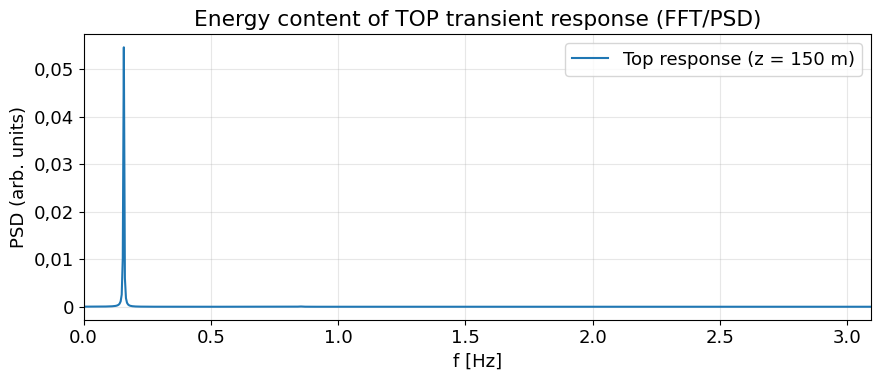

--- Dominant frequency from TOP transient response ---
Top elevation z = 150.000 m
f_peak = 0.158332 Hz
Natural frequencies (Hz): [0.15777, 0.85312, 2.062196]
Closest mode = 1, f_n = 0.157770 Hz


In [76]:
# FFT / PSD and dominant energy frequency at the tower top (z = H_turb)
from matplotlib.ticker import FuncFormatter

x_detr = x_top - np.mean(x_top)
N = len(x_detr)
Xf = np.fft.rfft(x_detr)
freq = np.fft.rfftfreq(N, d=dt)
PSD = (np.abs(Xf) ** 2) / (N * fs)

idx_peak = np.argmax(PSD[1:]) + 1 if len(PSD) > 1 else 0
f_peak = float(freq[idx_peak])
closest_mode = int(np.argmin(np.abs(freq_n - f_peak)))

def comma_trim(y, _):
    s = f"{y:.10f}".rstrip('0').rstrip('.')
    if s in ('', '-0'):
        s = '0'
    return s.replace('.', ',')

plt.figure(figsize=(9, 4))
plt.plot(freq, PSD, color='tab:blue', label=f'Top response (z = {H_turb:.0f} m)')
plt.xlim(0.0, max(1.5 * float(np.max(freq_n)), 0.5))
plt.xlabel('f [Hz]')
plt.ylabel('PSD (arb. units)')
plt.title('Energy content of TOP transient response (FFT/PSD)')
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
ax.yaxis.set_major_formatter(FuncFormatter(comma_trim))

plt.legend()
plt.tight_layout()
plt.show()

print('--- Dominant frequency from TOP transient response ---')
print(f'Top elevation z = {H_turb:.3f} m')
print(f'f_peak = {f_peak:.6f} Hz')
print('Natural frequencies (Hz):', [float(f"{v:.6f}") for v in freq_n])
print(f'Closest mode = {closest_mode + 1}, f_n = {freq_n[closest_mode]:.6f} Hz')

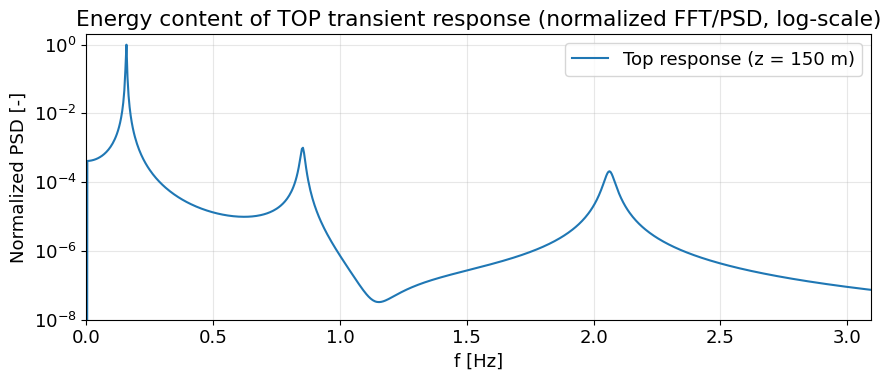

In [71]:
# Extra plot: TOP PSD normalized by its own maximum, with log-scale y-axis
from matplotlib.ticker import FuncFormatter

PSD_norm = PSD / (np.max(PSD) + 1e-30)

def comma_trim(y, _):
    s = f"{y:.10f}".rstrip('0').rstrip('.')
    if s in ('', '-0'):
        s = '0'
    return s.replace('.', ',')

plt.figure(figsize=(9, 4))
plt.plot(freq, PSD_norm, color='tab:blue', label=f'Top response (z = {H_turb:.0f} m)')
plt.xlim(0.0, max(1.5 * float(np.max(freq_n)), 0.5))
plt.yscale('log')
plt.ylim(1e-8, 2.0)
plt.xlabel('f [Hz]')
plt.ylabel('Normalized PSD [-]')
plt.title('Energy content of TOP transient response (normalized FFT/PSD, log-scale)')
plt.grid(True, alpha=0.3)

# Keep scientific 10^ notation on normalized log-scale axis
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.LogFormatterMathtext())

plt.legend()
plt.tight_layout()
plt.show()

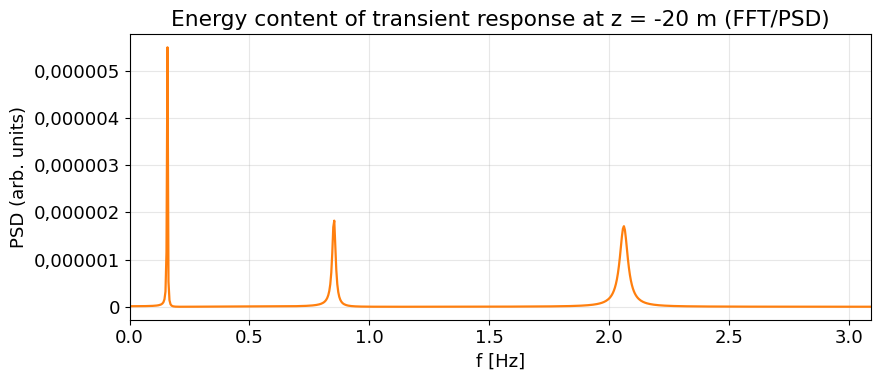

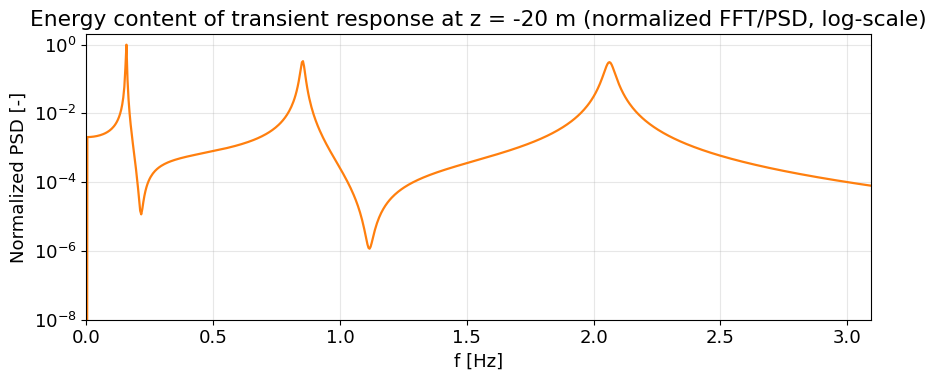

In [77]:
# PSD and normalized PSD at one selected elevation (z = -20 m)
from matplotlib.ticker import FuncFormatter

W1_eval = sp.lambdify((z_sym, omega_sym, A1, B1, C1, D1, A2, B2, C2, D2), W1_num, 'numpy')
W2_eval = sp.lambdify((z_sym, omega_sym, A1, B1, C1, D1, A2, B2, C2, D2), W2_num, 'numpy')

def mode_consts(om):
    Kw = Knum(om)
    _, _, Vh = np.linalg.svd(Kw)
    cst = Vh.conj().T[:, -1]
    return cst / (np.max(np.abs(cst)) + 1e-16)

def phi_at_z(zq, om, cst):
    A1v, B1v, C1v, D1v, A2v, B2v, C2v, D2v = cst
    scale = np.real(W2_eval(H_turb, om, A1v, B1v, C1v, D1v, A2v, B2v, C2v, D2v))
    scale = float(scale) if abs(scale) > 1e-14 else 1.0
    if zq <= 0.0:
        return float(np.real(W1_eval(zq, om, A1v, B1v, C1v, D1v, A2v, B2v, C2v, D2v)) / scale)
    return float(np.real(W2_eval(zq, om, A1v, B1v, C1v, D1v, A2v, B2v, C2v, D2v)) / scale)

# Selected elevation
z_sel = -20.0

def comma_trim(y, _):
    s = f"{y:.10f}".rstrip('0').rstrip('.')
    if s in ('', '-0'):
        s = '0'
    return s.replace('.', ',')

# Modal participation at selected elevation
phi_sel = np.zeros(len(omega_n), dtype=float)
for n, om in enumerate(omega_n):
    cst = mode_consts(float(om))
    phi_sel[n] = phi_at_z(float(z_sel), float(om), cst)

# Reconstruct local response and compute PSD
x_sel = (phi_sel @ q) - np.mean(phi_sel @ q)
X_sel = np.fft.rfft(x_sel)
PSD_sel = (np.abs(X_sel) ** 2) / (len(x_sel) * fs)
PSD_sel_norm = PSD_sel / (np.max(PSD_sel) + 1e-30)

# Figure 1: Absolute PSD (orange for z=-20 m)
plt.figure(figsize=(9, 4))
plt.plot(freq, PSD_sel, lw=1.6, color='tab:orange')
plt.xlim(0.0, max(1.5 * float(np.max(freq_n)), 0.5))
plt.xlabel('f [Hz]')
plt.ylabel('PSD (arb. units)')
plt.title(f'Energy content of transient response at z = {z_sel:.0f} m (FFT/PSD)')
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
ax.yaxis.set_major_formatter(FuncFormatter(comma_trim))

plt.tight_layout()
plt.show()

# Figure 2: Normalized PSD (orange for z=-20 m)
plt.figure(figsize=(9, 4))
plt.plot(freq, PSD_sel_norm, lw=1.6, color='tab:orange')
plt.xlim(0.0, max(1.5 * float(np.max(freq_n)), 0.5))
plt.yscale('log')
plt.ylim(1e-8, 2.0)
plt.xlabel('f [Hz]')
plt.ylabel('Normalized PSD [-]')
plt.title(f'Energy content of transient response at z = {z_sel:.0f} m (normalized FFT/PSD, log-scale)')
plt.grid(True, alpha=0.3)

# Keep scientific 10^ notation for normalized axis
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.LogFormatterMathtext())

plt.tight_layout()
plt.show()